# 📊 Analyse exploratoire (EDA) du dataset Housing

**Objectif :** explorer le jeu de données immobilier — statistiques descriptives, graphiques, moyennes par groupe — puis quantifier la relation surface/prix avec une **régression linéaire** (via `scipy`).

L'**analyse exploratoire** (*Exploratory Data Analysis*) est toujours la première étape avant de modéliser : elle permet de comprendre les données, repérer les anomalies et choisir les bonnes variables.

---
Import de **pandas**, la bibliothèque de manipulation de tableaux de données.

In [1]:
import pandas as pd

Import de **numpy**, la bibliothèque de calcul numérique.

In [2]:
import numpy as np

Chargement du fichier CSV dans un **DataFrame**.

In [3]:
df = pd.read_csv("../Data/Housing_2.csv")


`.columns` liste les noms de toutes les colonnes — utile pour savoir ce que contient le dataset.

In [4]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

### 🧠 Théorie : les statistiques descriptives (`describe`)

Pour chaque colonne numérique, `describe()` calcule :

| Statistique | Signification |
|---|---|
| `count` | nombre de valeurs |
| `mean` | moyenne : $\bar{x} = \frac{1}{n}\sum_i x_i$ |
| `std` | écart-type : $s = \sqrt{\frac{1}{n-1}\sum_i (x_i - \bar{x})^2}$ — mesure la dispersion autour de la moyenne |
| `min` / `max` | valeurs extrêmes |
| `25%`, `50%`, `75%` | **quartiles** ; le 50 % est la **médiane** (la moitié des valeurs sont en dessous) |

💡 Si la moyenne est très différente de la médiane, la distribution est **asymétrique** (souvent à cause de valeurs extrêmes).

In [172]:
df.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862,0.465138
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302,0.380686
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000


Affichage du DataFrame complet pour avoir une vue d'ensemble.

In [173]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0.5
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0.0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,0.5
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0.0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,1.0


`.drop(["stories"], axis=1)` supprime la colonne `stories` (nombre d'étages). `axis=1` = « colonne ». La réaffectation `df = ...` est nécessaire car `drop` renvoie une **copie** (il ne modifie pas le DataFrame original).

In [174]:
df = df.drop(["stories"],axis = 1)

In [175]:
df

,price,area,bedrooms,bathrooms,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,1,0,0,0,1,2,1,1.0
1,12250000,8960,4,4,1,0,0,0,1,3,0,1.0
2,12250000,9960,3,2,1,0,1,0,0,2,1,0.5
3,12215000,7500,4,2,1,0,1,0,1,3,1,1.0
4,11410000,7420,4,1,1,1,1,0,1,2,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,0,1,0,0,2,0,0.0
541,1767150,2400,3,1,0,0,0,0,0,0,0,0.5
542,1750000,3620,2,1,1,0,0,0,0,0,0,0.0
543,1750000,2910,3,1,0,0,0,0,0,0,0,1.0


### Nuage de points : surface vs prix

On cherche visuellement une **tendance linéaire** (plus la surface est grande, plus le prix est élevé).

**🔍 Comment interpréter ce graphique :**
- **Tendance générale** : si les points montent globalement de la gauche vers la droite, la relation area→price est bien positive — bon signe pour une régression linéaire.
- **Dispersion** : regarde si les points s'écartent de plus en plus de la tendance à mesure que la surface augmente (forme d'entonnoir/éventail qui s'ouvre) — c'est de l'**hétéroscédasticité** : la variance du prix n'est pas constante, elle grandit avec la surface. C'est un signal que la régression linéaire simple aura plus de mal à prédire précisément les grandes maisons.
- **Points isolés (outliers)** : une maison avec un prix très élevé pour une petite surface (ou l'inverse) peut indiquer une variable manquante importante (quartier, standing, rénovation…) qui influence le prix indépendamment de la surface.

<Axes: xlabel='area', ylabel='price'>

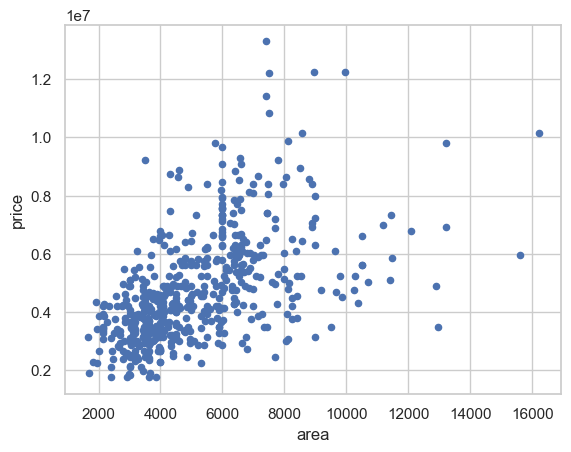

In [176]:
df.plot.scatter(x = "area", y = "price")

### 🧠 Le `groupby` : « split – apply – combine »

`df.groupby("furnishingstatus")["price"].mean()` fonctionne en 3 temps :
1. **Split** : sépare les lignes en groupes selon `furnishingstatus` (meublé / semi-meublé / non meublé)
2. **Apply** : calcule la **moyenne** du prix dans chaque groupe
3. **Combine** : rassemble les résultats en une Series

👉 On obtient le **prix moyen par statut d'ameublement** — première façon de voir si une variable catégorielle influence le prix.

In [177]:
df.groupby("furnishingstatus")["price"].mean()

furnishingstatus
0.0    4.013831e+06
0.5    4.907524e+06
1.0    5.495696e+06
Name: price, dtype: float64

Même logique par **nombre de chambres**, enchaînée directement avec `.plot.bar()` pour un diagramme en barres — chaque barre = le prix **moyen** des maisons ayant ce nombre de chambres.

**🔍 Comment interpréter ce graphique :**
- **Tendance attendue** : plus il y a de chambres, plus le prix moyen devrait grimper — vérifie que c'est globalement le cas.
- **Attention aux petits effectifs** : les catégories avec très peu de maisons (ex : 5 ou 6 chambres) reposent sur peu d'exemples — leur moyenne peut être bruyante et ne pas suivre la tendance générale (une seule maison très chère ou très bon marché peut beaucoup faire varier la barre).
- **Ce que ce graphique ne montre PAS** : la dispersion à l'intérieur de chaque catégorie (deux maisons à 3 chambres peuvent avoir des prix très différents) — pour ça, il faudrait un boxplot plutôt qu'un simple graphique de moyennes.

<Axes: xlabel='bedrooms'>

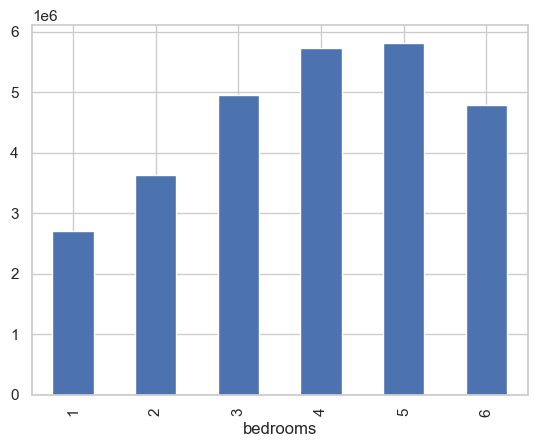

In [178]:
df.groupby("bedrooms")["price"].mean().plot.bar()

Préparation d'un graphique plus soigné avec **seaborn** :
- `sns.set(style="whitegrid")` : fond blanc quadrillé.
- `as_index=False` : garde `furnishingstatus` comme **colonne normale** (au lieu d'index) → nécessaire pour le `barplot` de seaborn qui attend des noms de colonnes.

In [179]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
avg_price = df.groupby("furnishingstatus",as_index = False)["price"].mean()


`type(...)` confirme que le résultat est un **DataFrame** (grâce à `as_index=False` ; sinon ce serait une Series).

In [180]:

type(avg_price)

pandas.DataFrame

Affichage du petit tableau des moyennes.

In [181]:
avg_price

,furnishingstatus,price
0,0.0,4.013831e+06
1,0.5,4.907524e+06
2,1.0,5.495696e+06


### Graphique en barres avec matplotlib + seaborn
- `plt.figure(figsize=(10,5))` : crée la figure et fixe sa taille (largeur, hauteur en pouces)
- `plt.title / xlabel / ylabel` : titre et étiquettes des axes
- `sns.barplot(...)` : dessine les barres ; `palette="pastel"` choisit les couleurs

Chaque barre = le **prix moyen** d'une catégorie.

**🔍 Comment interpréter ce graphique :** compare les 3 barres (furnished / semi-furnished / unfurnished). On s'attend logiquement à ce qu'un logement **meublé** se loue/vende plus cher qu'un logement **non meublé**, à surface égale — vérifie si l'ordre des barres correspond à cette intuition. Si l'ordre est surprenant (ex : non meublé plus cher que meublé), cela peut signaler que d'autres facteurs (surface, quartier) sont confondus avec le statut d'ameublement dans ce dataset.

C:\Users\kirit\AppData\Local\Temp\ipykernel_3152\294986194.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price,x = "furnishingstatus", y= "price", palette = "pastel")


<Axes: title={'center': 'Average price by furnishing status'}, xlabel='Furnishing Status', ylabel='Average Price'>

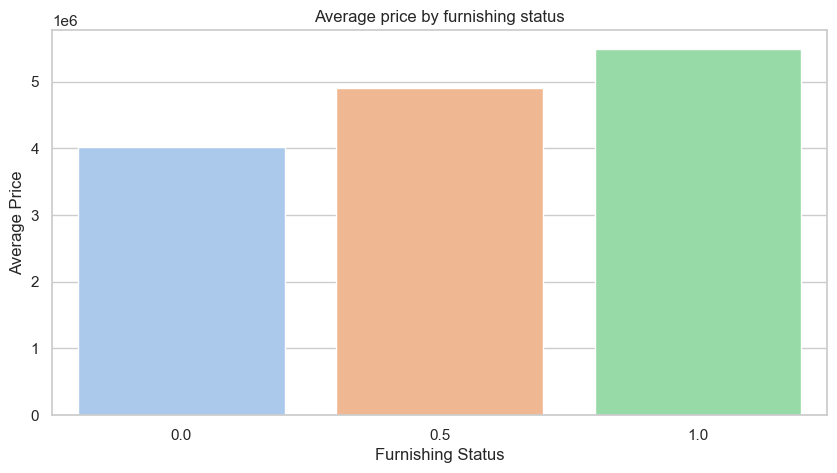

In [182]:
plt.figure(figsize = (10,5))
plt.title("Average price by furnishing status")
plt.xlabel("Furnishing Status")
plt.ylabel("Average Price")
sns.barplot(data=avg_price,x = "furnishingstatus", y= "price", palette = "pastel")


Même graphique mais par **nombre de chambres**. ⚠️ Petit bug cosmétique : le titre et les labels ont été copiés de la cellule précédente et parlent encore de « furnishing status » alors qu'on trace les chambres.

**🔍 Comment interpréter ce graphique :** comme pour le graphique en barres brut vu plus haut, on s'attend à une tendance croissante avec le nombre de chambres. Compare les deux versions (`.plot.bar()` simple vs ce `sns.barplot`) — les hauteurs de barres doivent raconter la même histoire, seule l'apparence change.

C:\Users\kirit\AppData\Local\Temp\ipykernel_3152\526085169.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price,x = "bedrooms", y= "price", palette = "pastel")


<Axes: title={'center': 'Average price by furnishing status'}, xlabel='Furnishing Status', ylabel='Average Price'>

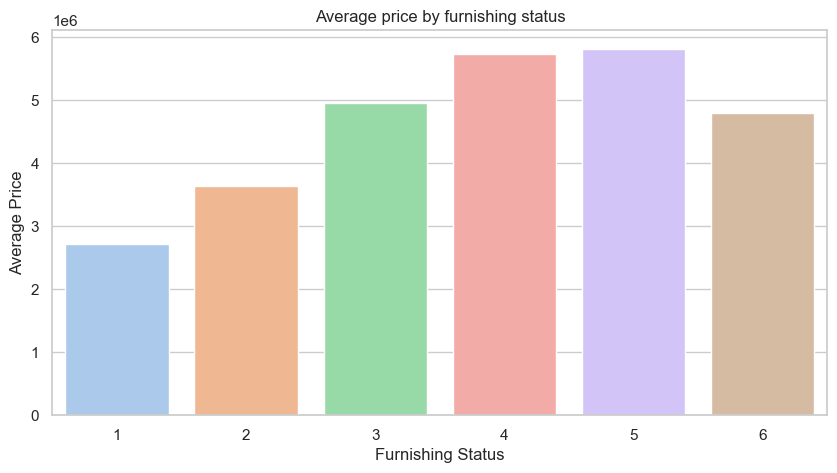

In [183]:
plt.figure(figsize = (10,5))
plt.title("Average price by furnishing status")
plt.xlabel("Furnishing Status")
plt.ylabel("Average Price")
avg_price = df.groupby("bedrooms",as_index = False)["price"].mean()
sns.barplot(data=avg_price,x = "bedrooms", y= "price", palette = "pastel")

### Nuage de points (grand format)

Même nuage de points area vs price que la toute première cellule de ce notebook, mais retracé en plus grand (`figsize=(10,10)`) avec seaborn plutôt que le `.plot.scatter()` de pandas.

💡 Remarque : la ligne `avg_price = df.groupby("bedrooms",...)` juste avant n'est pas utilisée dans ce graphique — c'est un reste de la cellule précédente, sans effet ici.

**🔍 Comment interpréter ce graphique :** exactement la même lecture que le tout premier scatter plot du notebook (tendance générale, dispersion croissante, points isolés) — le format plus grand permet simplement de mieux distinguer les points denses dans la zone des petites surfaces.

<Axes: title={'center': 'AREA VS PRICE'}, xlabel='AREA', ylabel='PRICE'>

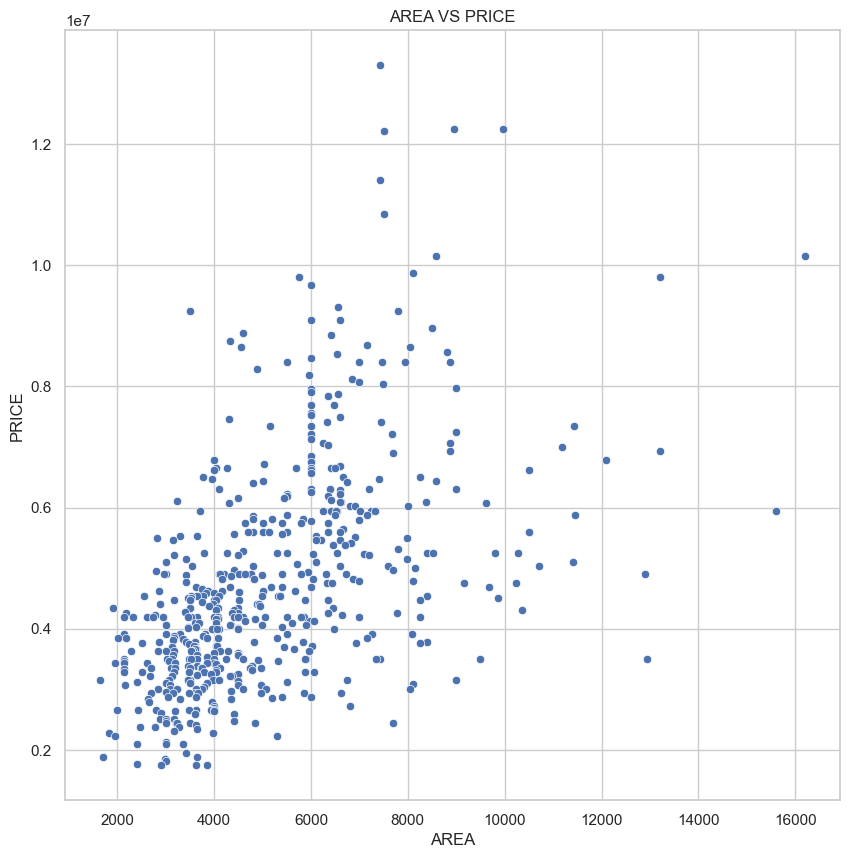

In [184]:
plt.figure(figsize = (10,10))
plt.title("AREA VS PRICE")
plt.xlabel("AREA")
plt.ylabel("PRICE")
avg_price = df.groupby("bedrooms",as_index = False)["price"].mean()
sns.scatterplot(df,x = "area", y= "price")

### 📈 `regplot` : le nuage de points + la droite de régression
`sns.regplot` superpose au nuage de points la **droite des moindres carrés** (en rouge ici) — la droite qui minimise la somme des erreurs au carré.
- `plt.xlim(0, 25000)` : limite l'axe des x
- `truncate=False` : prolonge la droite sur tout l'axe (pas seulement sur la plage des données)
- `plt.savefig("area_vs_price", dpi=300)` : exporte le graphique en PNG haute résolution (300 points par pouce). **À appeler avant que la figure soit affichée/fermée.**

**🔍 Comment interpréter ce graphique :** regarde l'écart entre les points et la droite rouge — plus les points sont proches de la droite, mieux la régression linéaire capture la relation. Si tu remarques que les points s'écartent de plus en plus de la droite pour les grandes surfaces (l'« entonnoir » déjà repéré sur le nuage de points brut), c'est le signe que le modèle linéaire sera moins précis sur les biens haut de gamme — cohérent avec la RMSE calculée dans S1_P2/S2_P1.

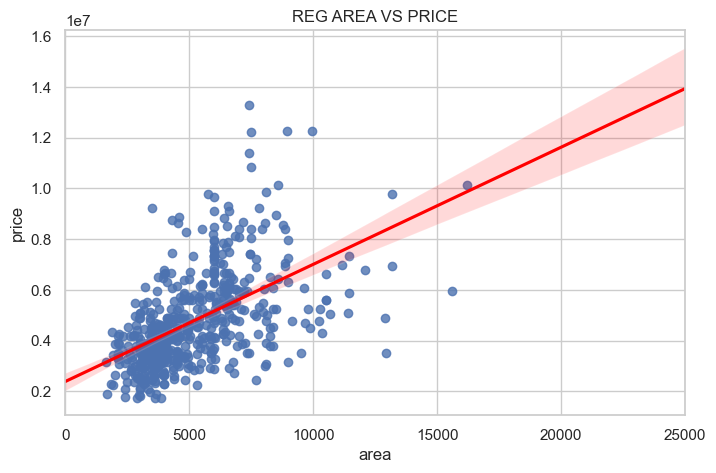

In [185]:
plt.figure(figsize = (8,5))
plt.title("REG AREA VS PRICE")
plt.xlabel("AREA")
plt.ylabel("PRICE")
plt.xlim(0,25000)
sns.regplot(data = df, x ="area", y = "price", line_kws = {"color":"red"}, truncate=False)
plt.savefig("area_vs_price",dpi=300)


`linregress` de **scipy** : calcule une régression linéaire simple ET les statistiques associées (corrélation, p-value…) — plus complet que `LinearRegression` de sklearn pour l'analyse statistique.

In [186]:
from scipy.stats import linregress

### 🧠 Théorie : ce que renvoie `linregress`

La fonction ajuste la droite $y = a\,x + b$ par moindres carrés et renvoie **5 valeurs** :

| Variable | Nom | Rôle |
|---|---|---|
| `slope` | pente $a$ | roupies gagnées par m² supplémentaire |
| `intercept` | ordonnée à l'origine $b$ | position verticale de la droite |
| `r_value` | corrélation $r$ de Pearson | force du lien linéaire (entre −1 et 1) |
| `p_value` | p-value | la relation est-elle statistiquement significative ? |
| `std_err` | erreur standard | incertitude sur la pente |

Chaque valeur est détaillée dans les cellules suivantes.

In [187]:
slope, intercept, r_value,p_value, std_err = linregress(df["area"], df["price"])

**La pente $a$** : pour chaque m² de surface en plus, le prix augmente en moyenne de cette valeur (en roupies).

In [188]:
slope

np.float64(461.9748942727829)

**L'ordonnée à l'origine $b$** : prix théorique d'une maison de 0 m² — sans sens physique, mais nécessaire à l'équation de la droite.

In [189]:
intercept

np.float64(2387308.4823964327)

### 🧠 Le coefficient de corrélation de Pearson $r$

$$r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}}$$

- $r = 1$ : relation linéaire croissante parfaite ; $r = -1$ : décroissante parfaite ; $r = 0$ : aucune relation **linéaire**
- Règle de lecture usuelle : $|r| > 0{,}7$ fort, $0{,}4$–$0{,}7$ modéré, $< 0{,}4$ faible
- Bonus : $r^2$ (le **coefficient de détermination**) = la **part de la variance du prix expliquée par la surface**. Ex. $r = 0{,}54 \Rightarrow r^2 \approx 0{,}29$ → la surface explique ~29 % des variations de prix.

In [190]:
r_value

np.float64(0.5359973457780794)

### 🧠 La p-value

Elle répond à la question : *« si en réalité il n'y avait **aucun lien** entre surface et prix (pente = 0), quelle serait la probabilité d'observer par pur hasard une pente au moins aussi forte que celle-ci ? »*

- **p < 0,05** (seuil usuel) → on rejette l'hypothèse « pas de lien » : la relation est **statistiquement significative** ✅
- Une p-value minuscule (ex. $10^{-40}$) signifie que le lien est quasi certain — mais elle ne dit **pas** qu'il est fort (c'est le rôle de $r$).

In [191]:
p_value

np.float64(7.38822540152335e-42)

### 🧠 L'erreur standard de la pente

C'est l'**incertitude** sur la valeur estimée de $a$ : avec un autre échantillon de maisons, la pente varierait d'environ ± cette valeur. Intervalle de confiance à ~95 % : $a \pm 2 \times \text{std\_err}$. Plus l'échantillon est grand et les points serrés autour de la droite, plus `std_err` est petit.

In [192]:
std_err

np.float64(31.22563550329104)

⚠️ **Attention :** ce `savefig` est appelé seul, sans figure active (la figure de la cellule 17 a déjà été affichée puis fermée par Jupyter). Il risque d'enregistrer une **image vide**. La bonne pratique : appeler `plt.savefig(...)` **dans la même cellule** que le tracé, avant `plt.show()`.

In [193]:
plt.savefig("area_vs_price",dpi=300)

<Figure size 640x480 with 0 Axes>